In [1]:
#EDA notebook
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Questions we want to answer: What distinguishes legitimate transactions from fraudulent ones?

In [3]:
df = pd.read_csv("../data/processed/cleaned_transactions.csv")

<Axes: xlabel='is_fraud', ylabel='count'>

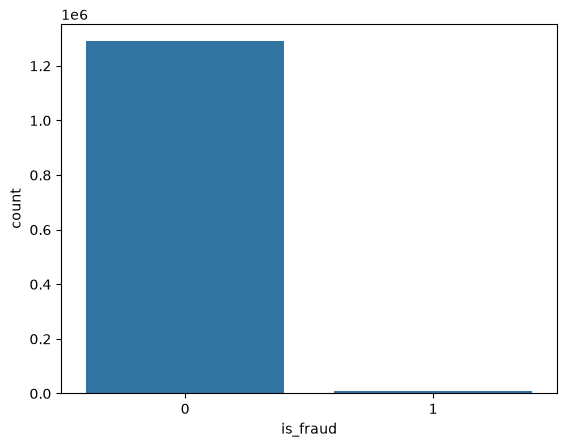

In [4]:
sns.countplot(data=df, x="is_fraud")

In [5]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

In [ ]:
# The class distribution reveals a severe class imbalance, with legitimate transactions 
# accounting for more than 99% of the dataset while fraudulent transactions represent less than 1%. 
#This imbalance is typical in real-world financial fraud detection, as fraudulent activity is relatively rare. 
#Consequently, relying on accuracy alone would be misleading, since a model could achieve high accuracy by predicting 
#every transaction as legitimate. Therefore, subsequent model evaluation will emphasize precision, 
#recall, F1-score, and ROC-AUC to better assess the model's ability to detect fraudulent transactions.

<Axes: xlabel='amt', ylabel='Count'>

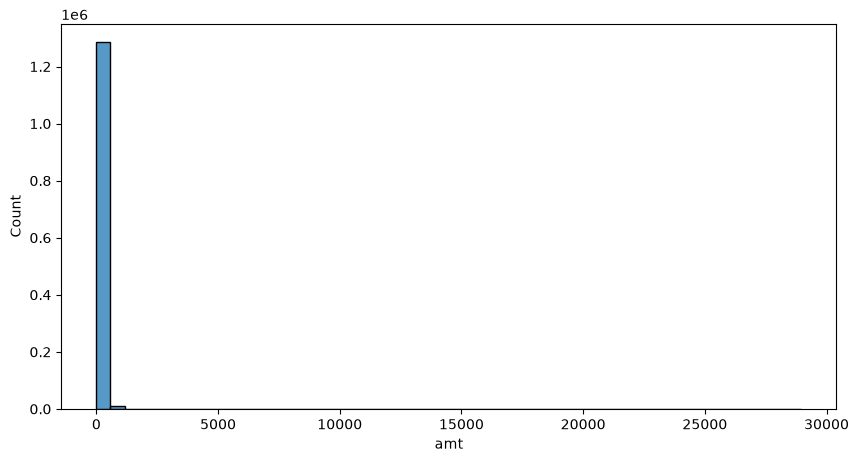

In [13]:
#Visualize transaction amount distribution
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x="amt",
    bins=50
)

<Axes: xlabel='is_fraud', ylabel='amt'>

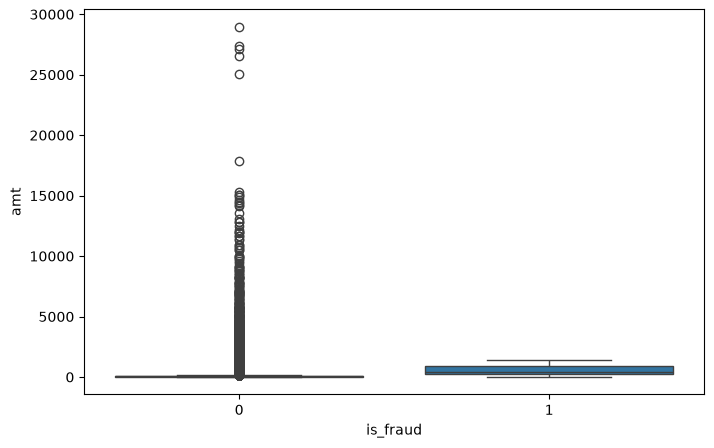

In [12]:
#Fraud vs Amount
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="is_fraud",
    y="amt"
)

<Axes: xlabel='count', ylabel='category'>

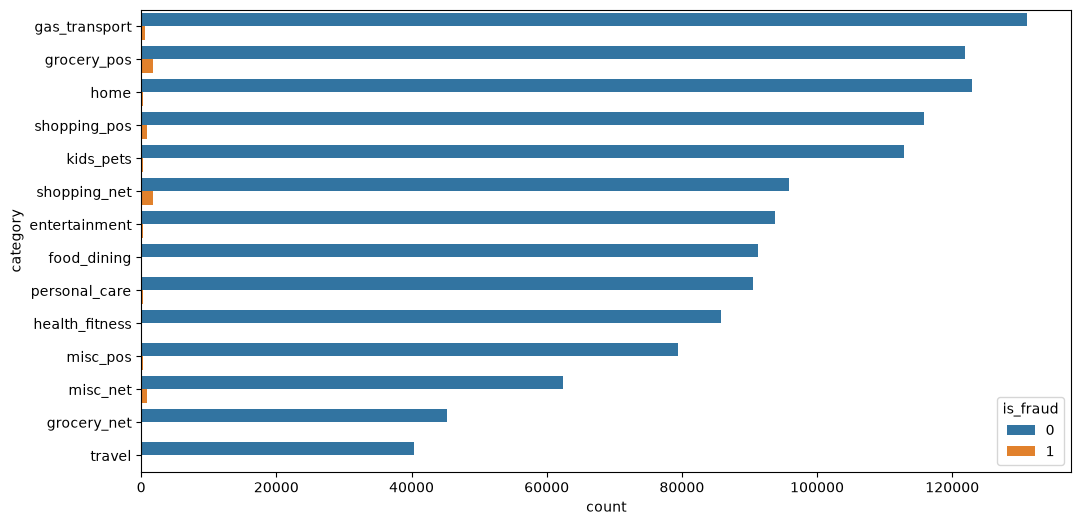

In [11]:
#Visualizing insight for fraud by business category
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="category",
    hue="is_fraud",
    order=df["category"].value_counts().index
)

<Axes: xlabel='gender', ylabel='count'>

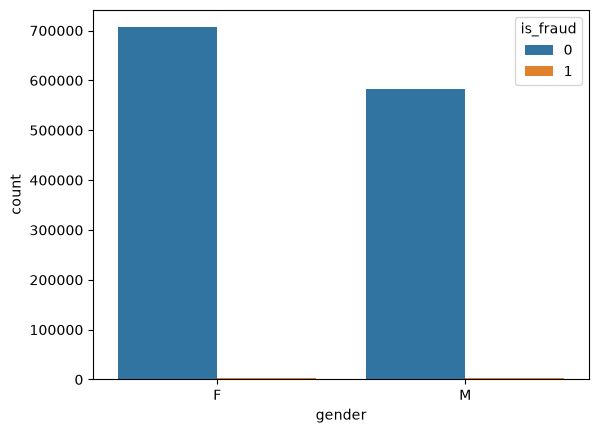

In [9]:
#Visualizations for fraud by gender
sns.countplot(
    data=df,
    x="gender",
    hue="is_fraud"
)

<Axes: xlabel='day_of_week', ylabel='count'>

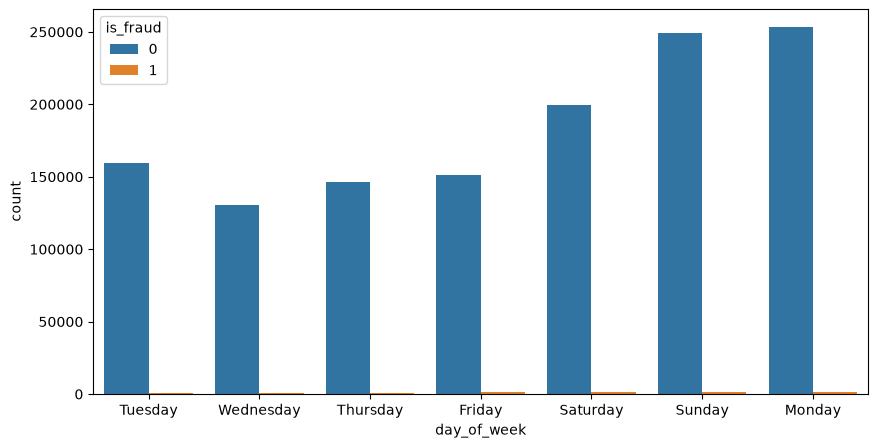

In [10]:
#checking day of week where fraudulent activity is most likely to occur
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="day_of_week",
    hue="is_fraud"
)

<Axes: xlabel='is_weekend', ylabel='count'>

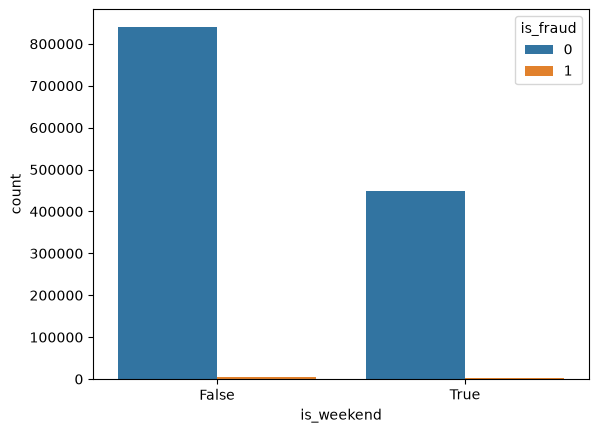

In [14]:
#plot for fraudulent activity occuring over the weekend
sns.countplot(
    data=df,
    x="is_weekend",
    hue="is_fraud"
)

<Axes: xlabel='is_fraud', ylabel='distance_km'>

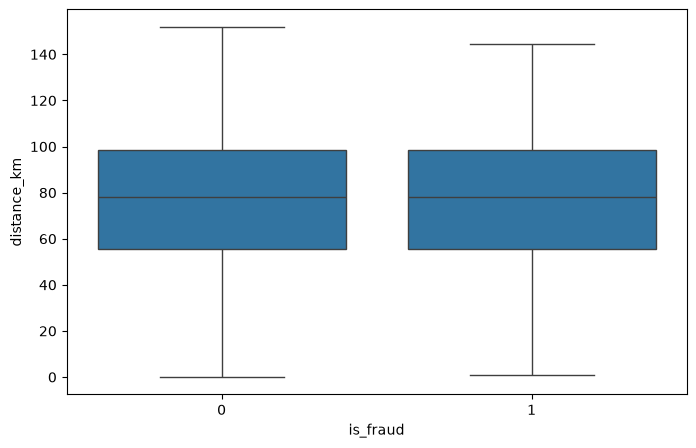

In [18]:
#Customer vs merchant Distance
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="is_fraud",
    y="distance_km"
)

<Axes: >

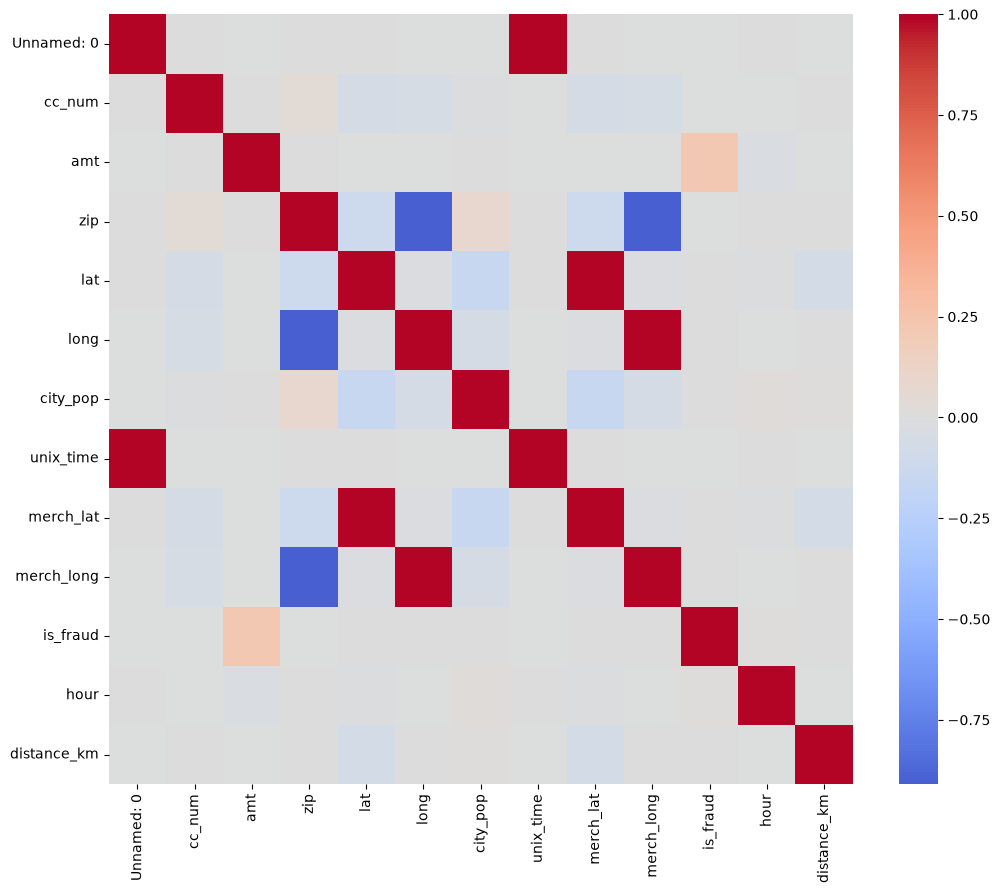

In [19]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,10))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

In [20]:
#Features most correlated with fraud
numeric_df.corr()["is_fraud"] \
    .sort_values(ascending=False)

is_fraud       1.000000
amt            0.219404
hour           0.013799
city_pop       0.002136
lat            0.001894
merch_lat      0.001741
merch_long     0.001721
long           0.001721
distance_km    0.000404
cc_num        -0.000981
zip           -0.002162
Unnamed: 0    -0.004767
unix_time     -0.005078
Name: is_fraud, dtype: float64